# Dynamic wheat-leaf disease image series: loading & inspection with the authors' DatasetTools

**Paper:** Jonas Anderegg (2026). *High-Resolution Leaf Image Sequences with Geometric Alignment for Dynamic Phenotyping of Foliar Diseases.* **Scientific Data 13:247 (2026)**. Paper record DOI: [10.3929/ethz-c-000796858](https://doi.org/10.3929/ethz-c-000796858)

**Dataset:** Anderegg, J. (2025), *High-Resolution Leaf Image Sequences with Geometric Alignment for Dynamic Trait Extraction*, ETH Zurich, DOI [10.3929/ethz-b-000739194](https://doi.org/10.3929/ethz-b-000739194) (**CC-BY-4.0**). The record links the actual data on a public ETH LibDrive share.

**Code:** [and-jonas/sympathique-wheat](https://github.com/and-jonas/sympathique-wheat), pinned commit `d580937d47a0083e177c0f9aa3effe22638ee139` (master HEAD, verified 2026-10-09). The repository publishes no LICENSE file — the Python code is used here under the paper's stated availability; the dataset itself is CC-BY-4.0.

**Scope (partial demonstration, executed):** reproduce the paper's *dataset-loading / inspection* use case with the authors' own `DatasetTools.LeafDataset`: load **one** wheat-leaf image series (`ESWW0070020_1`, season 2023 — the first sample of the dataset's `processed/reg` listing, chosen deterministically before viewing any content), inspect its published registration products (ROI + piecewise-affine transforms, aligned crops, masks) and symptom-tracking products (lesion instance masks), and re-run the author's `warp_images()` from the raw images to cross-check the published aligned outputs. This is **CPU-only**; no trained model is needed.

**Not in scope:** reference-mark detection (YOLOv8, `models/best.pt`), symptom detection/segmentation inference, re-running the tracker, the 2024 season, and dataset-level trait tables (`res/*.rds`, R data).

*日本語:* 本ノートブックは、論文「High-Resolution Leaf Image Sequences...」(Scientific Data 13:247, 2026) が公開する小麦葉の高解像度時系列画像データセットと、著者らの `DatasetTools` を用いて、**1 系列**の葉画像の読み込み・検査（レジストレーション成果物と症状トラッキング・マスクの確認、`warp_images()` による整合の再計算と照合）を行います。CPU のみで実行でき、学習済みモデルは不要です。""


## Runtime selection & Run all

**Select Runtime → Change runtime type → CPU** (no GPU needed; none of the executed operations use torch). Soft expectations on a fresh free-tier runtime: **~10–20 min total**, **~500 MB** of downloads (one leaf series of raw JPGs + its processed outputs). Everything runs under `/content` on the Colab VM.

*日本語:* 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。GPU は不要です。全体で約 10〜20 分、ダウンロード約 500 MB（生画像 1 系列分と処理済み成果物）を見込んでください。


### Setup: install the few packages the authors' code needs

The author toolkit (`DatasetTools`) needs `natsort` (natural sorting of file names) and OpenCV; everything else (numpy, scipy, scikit-image, pandas, matplotlib, Pillow) is preinstalled on Colab. We only install what is missing.

*日本語:* 著者コードに必要な小規模な依存パッケージ（`natsort`、必要なら OpenCV）だけを追加インストールします。

In [ ]:
import importlib.util, subprocess, sys

def ensure_pip(pkg, import_name=None):
    if importlib.util.find_spec(import_name or pkg) is None:
        print("installing", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_pip("natsort")                      # natural sorting used by DatasetTools.utils.get_series
if importlib.util.find_spec("cv2") is None:
    ensure_pip("opencv-python-headless")   # headless build suffices on Colab
print("setup done")

setup done


### Environment report

Record the actual interpreter and library versions of this runtime (the authors used Python 3.10 with scikit-image 0.20 / numpy 1.26; Colab is newer, which matters for loading their pickle files below).

*日本語:* 実行環境のバージョンを記録します（著者環境より新しいライブラリでの動作確認に使用）。

In [ ]:
import sys
import numpy, scipy, pandas, matplotlib, PIL, skimage, natsort
print("python", sys.version.split()[0])
for m in (numpy, scipy, pandas, matplotlib, PIL, skimage, natsort):
    print(f"{m.__name__:12s} {m.__version__}")
import cv2
print(f"{'cv2':12s} {cv2.__version__}")

python 3.13.16
numpy        2.1.3
scipy        1.16.3
pandas       2.2.3
matplotlib   3.10.0
PIL          11.3.0
skimage      0.25.2
natsort      8.4.0
cv2          5.0.0


### Fetch the authors' `DatasetTools` verbatim from the pinned commit

Only the two files needed for the loading/inspection path are fetched, from raw.githubusercontent.com at the pinned commit. Each file's byte count and SHA-256 are asserted before use (values computed from the verified repository tree).

*日本語:* 著者の `DatasetTools` 2 ファイルのみ、コミット固定の URL から取得し、サイズと SHA-256 を検証します。

In [ ]:
import hashlib
from pathlib import Path
import urllib.request

COMMIT = "d580937d47a0083e177c0f9aa3effe22638ee139"  # master HEAD, verified via GitHub API 2026-10-09
CODE_DIR = Path("/content/sympathique/code")
PINNED = {
    "DatasetTools/LeafImageSeries.py": (
        28439, "cb07b59282b93223d437de510a5ccc2c5ecb453a6b9aab8fb605af13371f3334"),
    "DatasetTools/utils.py": (
        7430, "2a9065f6efff1ad4269f4adbf15638a4897cf0557cbd2233dbb7016e97698a4f"),
}
for rel, (size, sha) in PINNED.items():
    url = f"https://raw.githubusercontent.com/and-jonas/sympathique-wheat/{COMMIT}/{rel}"
    dest = CODE_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    data = urllib.request.urlopen(url, timeout=60).read()
    assert len(data) == size and hashlib.sha256(data).hexdigest() == sha, f"verification failed: {rel}"
    dest.write_bytes(data)
    print(f"verified {rel}: {len(data)} bytes, sha256 ok")

verified DatasetTools/LeafImageSeries.py: 28439 bytes, sha256 ok
verified DatasetTools/utils.py: 7430 bytes, sha256 ok


## Data access: the public ETH LibDrive share

The dataset DOI record (ETH Research Collection) stores the data on a **public read-only LibDrive (Nextcloud) share**; its URL is published in the record's metadata field `ethz.libdrive.url`. Nextcloud shares expose a read-only WebDAV view at `/public.php/webdav` (share token as the user, empty password) — no login and no credentials are involved. Here we define small helpers: `propfind` (folder listing with sizes) and `dav_get` (verified download).

*日本語:* データ実体は ETH の公開 LibDrive（Nextcloud）共有にあります。共有トークンによる読み取り専用 WebDAV で一覧取得（PROPFIND）とダウンロードを行うヘルパーを定義します（認証情報は不要）。

In [ ]:
import requests
from xml.etree import ElementTree as ET

SHARE_TOKEN = "Agn94FpGxtKyLkd"   # public share token (no password), from the dataset record metadata
WEBDAV = "https://libdrive.ethz.ch/public.php/webdav"

def propfind(rel_path, depth=1):
    """List a share folder -> {name: size_bytes or None for directories}."""
    r = requests.request("PROPFIND", f"{WEBDAV}/{rel_path}", auth=(SHARE_TOKEN, ""),
                         headers={"Depth": str(depth)}, timeout=60)
    r.raise_for_status()
    entries = {}
    for resp in ET.fromstring(r.content).iter("{DAV:}response"):
        name = resp.find("{DAV:}href").text.rstrip("/").split("/")[-1]
        cl = resp.find(".//{DAV:}getcontentlength")
        entries[name] = int(cl.text) if cl is not None else None
    return entries

def dav_get(rel_path, dest, expected_size=None):
    """Stream-download one share file and assert its size."""
    dest.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(f"{WEBDAV}/{rel_path}", auth=(SHARE_TOKEN, ""), stream=True, timeout=600) as r:
        r.raise_for_status()
        n = 0
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk); n += len(chunk)
    if expected_size is not None:
        assert n == expected_size, f"size mismatch {dest}: {n} != {expected_size}"
    return n

root = propfind("")
print("share root:", sorted(root))

share root: ['Readme.txt', 'doi.txt', 'meta', 'models', 'processed', 'raw', 'webdav']


### Enumerate the measurement events (2023)

The published layout (paper *Data Records*; dataset `Readme.txt`) is `raw/<year>/<measurement event>/*.JPG` with names `YYYYMMDD_HHMMSS_<plot>_<leaf>.JPG`, plus `processed/{reg,res,ts}/<leaf_uid>/...`. We list the 2023 events.

*日本語:* 公開レイアウトに従い、2023 年の撮影イベント（日付）フォルダ一覧を取得します。

In [ ]:
dates = sorted(n for n, s in propfind("raw/2023/").items() if s is None and n != "2023")
print(len(dates), "measurement events in 2023:")
print(dates)

31 measurement events in 2023:
['20230525', '20230526', '20230527_1', '20230527_2', '20230529', '20230530', '20230531_1', '20230531_2', '20230601', '20230602', '20230603', '20230604', '20230606', '20230607', '20230608', '20230609', '20230610', '20230612', '20230613', '20230614', '20230615', '20230616', '20230618', '20230619', '20230620', '20230621', '20230622', '20230623', '20230626', '20230627', '20230628']


### Select one leaf series and enumerate its raw images

`DatasetTools.utils.get_series` groups images by the `_".join(name.split("_")[2:4])` part of the file name — e.g. `20230525_172420_ESWW0070020_1.JPG` → leaf uid `ESWW0070020_1`. We take **`ESWW0070020_1`** (plot `ESWW007`, plant 0020, leaf 1), the **first** uid of the natsorted `processed/reg` listing — a deterministic choice made before seeing any image content. The listing below tells us how many raw frames to expect.

*日本語:* `get_series` の規則に合う葉 UID `ESWW0070020_1`（一覧の先頭要素を事前に決定的に選択）の生画像を全イベントから列挙します。

In [ ]:
LEAF_UID = "ESWW0070020_1"
YEAR = "2023"
leaf_images = []   # (event_date, file_name, size_bytes)
for date in dates:
    for name, size in propfind(f"raw/{YEAR}/{date}/").items():
        if name.endswith(".JPG") and "_".join(name[:-4].split("_")[2:4]) == LEAF_UID:
            leaf_images.append((date, name, size))
assert leaf_images, "no raw images matched the leaf filter - check the file-name convention"
total = sum(s for _, _, s in leaf_images)
print(f"{LEAF_UID}: {len(leaf_images)} raw images across {len({d for d, _, _ in leaf_images})} events, {total/1e6:.0f} MB total")
for date, name, size in leaf_images[:5]:
    print(f"  {date}  {name}  {size/1e6:.1f} MB")

ESWW0070020_1: 14 raw images across 14 events, 263 MB total
  20230525  20230525_172420_ESWW0070020_1.JPG  14.1 MB
  20230527_1  20230527_102010_ESWW0070020_1.JPG  16.6 MB
  20230527_2  20230527_164909_ESWW0070020_1.JPG  18.4 MB
  20230529  20230529_122541_ESWW0070020_1.JPG  18.3 MB
  20230530  20230530_122548_ESWW0070020_1.JPG  18.6 MB


### Download the raw frames of the selected series

Only this leaf's frames are downloaded (~16 MB each; full-frame Canon R5 JPGs), stored under `/content/sympathique/data/2023/<event>/` so that the author's `get_series` glob (`data/*/*/*.JPG`) finds them. Sizes are asserted against the listing.

*日本語:* 選択した葉の生画像のみを `data/2023/<イベント>/` にダウンロードします（サイズ照合あり）。

In [ ]:
from pathlib import Path
DATA_DIR = Path("/content/sympathique/data")
for date, name, size in leaf_images:
    dest = DATA_DIR / YEAR / date / name
    if dest.exists() and dest.stat().st_size == size:
        print("cached", name)
        continue
    n = dav_get(f"raw/{YEAR}/{date}/{name}", dest, expected_size=size)
    print(f"downloaded {name} ({n/1e6:.1f} MB)")

downloaded 20230525_172420_ESWW0070020_1.JPG (14.1 MB)


downloaded 20230527_102010_ESWW0070020_1.JPG (16.6 MB)


downloaded 20230527_164909_ESWW0070020_1.JPG (18.4 MB)


downloaded 20230529_122541_ESWW0070020_1.JPG (18.3 MB)


downloaded 20230530_122548_ESWW0070020_1.JPG (18.6 MB)


...

downloaded 20230603_105040_ESWW0070020_1.JPG (16.6 MB)


downloaded 20230604_132542_ESWW0070020_1.JPG (17.6 MB)


downloaded 20230606_084622_ESWW0070020_1.JPG (18.8 MB)


downloaded 20230607_162917_ESWW0070020_1.JPG (18.3 MB)


downloaded 20230608_162957_ESWW0070020_1.JPG (15.9 MB)


### Validate the raw image bytes

Every downloaded JPG is opened and verified with Pillow (this checks actual bytes, not just the transfer). We print the sensor dimensions of the first frame.

*日本語:* ダウンロードした生画像を Pillow で開いて検証します（バイト列の整合確認）。

In [ ]:
from PIL import Image
bad = []
for date, name, size in leaf_images:
    dest = DATA_DIR / YEAR / date / name
    try:
        with Image.open(dest) as im:
            im.verify()
    except Exception as e:
        bad.append((name, str(e)))
print(f"raw images verified: {len(leaf_images) - len(bad)}/{len(leaf_images)}, failed: {bad}")
with Image.open(DATA_DIR / YEAR / leaf_images[0][0] / leaf_images[0][1]) as im0:
    print("example frame:", im0.size, im0.mode)

raw images verified: 14/14, failed: []
example frame: (8192, 5464) RGB


### Download the published registration outputs for the series

`processed/reg/<leaf_uid>/` contains the authors' registration products: `roi/` (per-frame ROI JSON + piecewise-affine transform pickles), `result/piecewise/` (aligned crops) and `mask_aligned/piecewise/` (aligned symptom/leaf masks) — exactly the sub-folder names `LeafDataset` expects. These are small (~1.4 MB per aligned crop).

*日本語:* `processed/reg/<葉UID>/` から、`LeafDataset` が参照するレジストレーション成果物（roi、result/piecewise、mask_aligned/piecewise）を取得します。

In [ ]:
PROC = Path("/content/sympathique/processed")
reg_rel = f"processed/reg/{LEAF_UID}"
for sub in ["roi", "result/piecewise", "mask_aligned/piecewise"]:
    entries = propfind(f"{reg_rel}/{sub}/")
    files = {n: s for n, s in entries.items() if s is not None}
    for name, size in sorted(files.items()):
        dest = PROC / "reg" / LEAF_UID / sub / name
        if not (dest.exists() and dest.stat().st_size == size):
            dav_get(f"{reg_rel}/{sub}/{name}", dest, expected_size=size)
    print(f"{sub}: {len(files)} files downloaded")

roi: 27 files downloaded


result/piecewise: 14 files downloaded


mask_aligned/piecewise: 14 files downloaded


### Download the published tracking outputs

`processed/ts/<leaf_uid>/` holds the symptom-tracking products: `instance_mask/` (lesion instance masks; the paper's *symptom tracking* stage) and `leaf_mask/`. Both are small PNGs.

*日本語:* `processed/ts/<葉UID>/` からトラッキング成果物（ lesion の instance mask、leaf mask）を取得します。

In [ ]:
ts_rel = f"processed/ts/{LEAF_UID}"
for sub in ["instance_mask", "leaf_mask"]:
    entries = propfind(f"{ts_rel}/{sub}/")
    files = {n: s for n, s in entries.items() if s is not None}
    for name, size in sorted(files.items()):
        dest = PROC / "ts" / LEAF_UID / sub / name
        if not (dest.exists() and dest.stat().st_size == size):
            dav_get(f"{ts_rel}/{sub}/{name}", dest, expected_size=size)
    print(f"{sub}: {len(files)} files downloaded")

instance_mask: 10 files downloaded


leaf_mask: 14 files downloaded


### Map the published layout onto the paths `LeafDataset` expects

The author class expects a working directory with `data/*/*/*.JPG`, `Output/<leaf_uid>/...` and `Output/ts/<leaf_uid>/...`. We provide these with **symlinks only** — no file is moved or renamed, and the author code runs unmodified:

| `LeafDataset` path | published source |
| --- | --- |
| `data/2023/<event>/*.JPG` | downloaded raw subset |
| `Output/<leaf_uid>` | `processed/reg/<leaf_uid>` |
| `Output/ts` | `processed/ts` |

*日本語:* 公開レイアウトから著者コードが期待するパスへ、シンボリックリンクだけで対応付けます（ファイルの移動・改名なし）。

In [ ]:
import os
BASE = Path("/content/sympathique")
out = BASE / "Output"
out.mkdir(exist_ok=True)

def link(src: Path, dst: Path):
    if dst.is_symlink() or dst.exists():
        dst.unlink()
    dst.symlink_to(src)

link(PROC / "reg" / LEAF_UID, out / LEAF_UID)
link(PROC / "ts", out / "ts")
print("Output/:", sorted(p.name for p in out.iterdir()))

Output/: ['ESWW0070020_1', 'ts']


## Load the series with the authors' `LeafDataset`

This runs the authors' class verbatim (`DatasetTools/LeafImageSeries.py`): it globs the series, and loads images, ROI JSONs, piecewise-affine transform pickles, aligned crops, masks and tracking masks. The class prints its own warnings for frames that lack a transform (e.g. washed-off reference marks) — that is the dataset's real curation status, not an error. Note: the `*_tform_piecewise.pkl` files are Python pickles produced by the authors; we load them only inside this disposable Colab VM.

*日本語:* 著者の `LeafDataset` をそのまま実行し、画像・ROI・ピースワイズアフィン変換・整合画像・マスクを読み込みます。変換が無いフレーム（マーカー流出等）は著者コード自身が警告します。pickle は著者提供のデータセット内のものを、この使い捨て Colab VM 内でのみ読み込みます。

In [ ]:
import sys
sys.path.insert(0, "/content/sympathique/code")
from DatasetTools.LeafImageSeries import LeafDataset

LOAD = ("images", "tforms", "rois", "target_masks", "target_images", "instance_masks", "leaf_masks")
ds = LeafDataset("/content/sympathique", leaf_uid=LEAF_UID, load=LOAD)
n = len(ds.image_uids)
print(f"frames: {n}")
print(f"  with tform:        {sum(t is not None for t in ds.tforms)}")
print(f"  with roi json:     {sum(t is not None for t in ds.rois)}")
print(f"  with aligned img:  {sum(t is not None for t in ds.target_images)}")
print(f"  with align mask:   {sum(t is not None for t in ds.target_masks)}")
print(f"  with instance msk: {sum(t is not None for t in ds.instance_masks)}")
print(f"  with leaf mask:    {sum(t is not None for t in ds.leaf_masks)}")
print("first uids:", ds.image_uids[:3])

frames: 14
  with tform:        13
  with roi json:     14
  with aligned img:  14
  with align mask:   14
  with instance msk: 10
  with leaf mask:    14
first uids: ['20230525_172420_ESWW0070020_1.JPG', '20230527_102010_ESWW0070020_1.JPG', '20230527_164909_ESWW0070020_1.JPG']


### Preview one raw input

Frame 0 of the series, shown at display resolution (the stored image is full-frame; its true pixel size is printed in the title). This is the actual acquired input the paper's pipeline starts from.

*日本語:* 系列の最初のフレーム（生画像）を表示します。タイトルに実際の画素数を表示します。

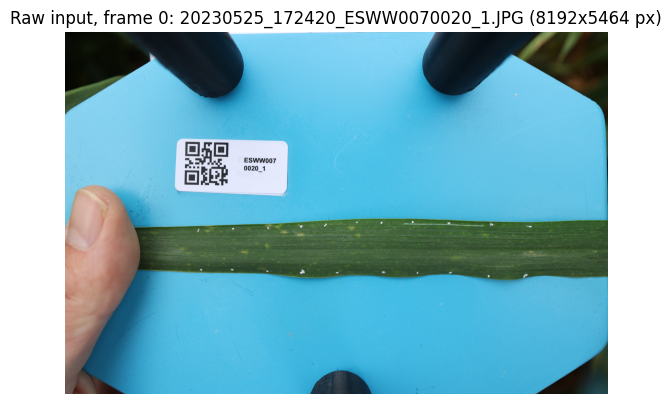

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img0 = np.asarray(ds.images[0])
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img0)
ax.set_title(f"Raw input, frame 0: {ds.image_uids[0]} ({img0.shape[1]}x{img0.shape[0]} px)")
ax.axis("off")
plt.show()

### Input vs published registration & annotation products

For the first frame that has published lesion **instance masks**, we show three panels: (1) the raw input, (2) the authors' published aligned crop (`result/piecewise`), and (3) the published aligned image with the published lesion instance masks overlaid. The masks are the dataset's published annotation products (the authors' model outputs delivered with the dataset) — **not** a new prediction made here.

*日本語:* instance mask が存在する最初のフレームについて、生画像・公開済み整合画像・公開済み lesion instance mask の重ね合わせを表示します。マスクはデータセット同梱の published annotation（著者モデルの出力）であり、本ノートブックでの新規予測ではありません。

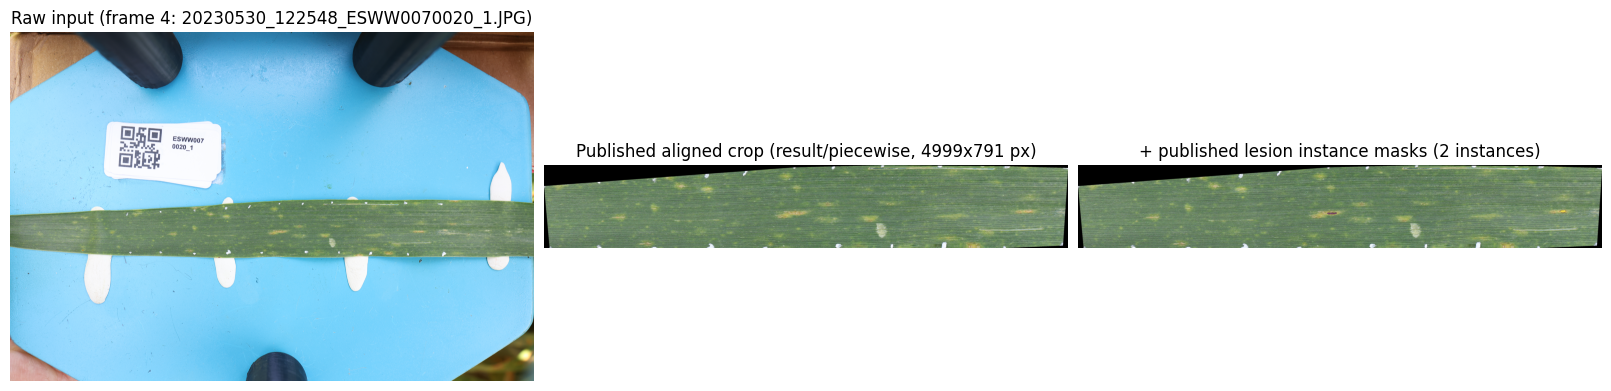

instance mask value range: 0 - 2


In [ ]:
i = next(k for k, m in enumerate(ds.instance_masks) if m is not None)
img_al = np.asarray(ds.target_images[i].convert("RGB"))
imsk = np.asarray(ds.instance_masks[i])
if imsk.ndim == 3:
    imsk = imsk[..., 0]
n_inst = int(imsk.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
axes[0].imshow(np.asarray(ds.images[i]))
axes[0].set_title(f"Raw input (frame {i}: {ds.image_uids[i]})")
axes[1].imshow(img_al)
axes[1].set_title(f"Published aligned crop (result/piecewise, {img_al.shape[1]}x{img_al.shape[0]} px)")
axes[2].imshow(img_al)
axes[2].imshow(np.ma.masked_where(imsk == 0, imsk), cmap="viridis", alpha=0.6)
axes[2].set_title(f"+ published lesion instance masks ({n_inst} instances)")
for ax in axes:
    ax.axis("off")
plt.show()
print("instance mask value range:", int(imsk.min()), "-", n_inst)

## Cross-check: re-run the registration from the raw images

The paper reports a median alignment error of 0.16 mm (≈5 px). Here we reproduce the registration *computationally* with the author's own `LeafDataset.warp_images()`: it rotates/crops each raw frame using the published ROI and applies the published piecewise-affine transform. We compare each re-generated crop against the authors' published aligned crop (`result/piecewise`). This is an **additional plausibility check created for this notebook** — mean absolute per-pixel difference is not a metric reported in the paper.

*日本語:* 著者の `warp_images()` を生画像から再実行し、公開済み整合画像との平均絶対差（0–255）を比較します。これは本ノートブック独自の追加検証であり、論文で報告された指標ではありません。

In [ ]:
ds.warp_images()
diffs = []
for warp, pub in zip(ds.warped_images, ds.target_images):
    if warp is None or pub is None:
        diffs.append(None)
        continue
    a = np.asarray(warp, dtype=np.int16)
    b = np.asarray(pub.convert("RGB"), dtype=np.int16)
    if a.shape != b.shape:
        print(f"  note: shape differs re-generated {a.shape} vs published {b.shape} (comparing overlap)")
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    diffs.append(float(np.abs(a[:h, :w] - b[:h, :w]).mean()))

for k, d in enumerate(diffs):
    if d is not None:
        print(f"frame {k:2d} ({ds.image_uids[k]}): mean |diff| = {d:6.2f}/255")
print("frames without published transform are skipped (author code falls back to the unaligned crop)")

Processing series:   0%|          | 0/14 [00:00<?, ?it/s]

Processing series:   7%|▋         | 1/14 [00:00<00:07,  1.78it/s]

Processing series:  14%|█▍        | 2/14 [00:04<00:30,  2.54s/it]

Processing series:  21%|██▏       | 3/14 [00:07<00:31,  2.86s/it]

Processing series:  29%|██▊       | 4/14 [00:10<00:29,  3.00s/it]

...

Processing series:  86%|████████▌ | 12/14 [00:38<00:06,  3.42s/it]

Processing series:  93%|█████████▎| 13/14 [00:41<00:03,  3.39s/it]

Processing series: 100%|██████████| 14/14 [00:44<00:00,  3.27s/it]

Processing series: 100%|██████████| 14/14 [00:44<00:00,  3.17s/it]

frame  0 (20230525_172420_ESWW0070020_1.JPG): mean |diff| =   1.16/255
frame  1 (20230527_102010_ESWW0070020_1.JPG): mean |diff| =   1.08/255
frame  2 (20230527_164909_ESWW0070020_1.JPG): mean |diff| =   1.29/255
frame  3 (20230529_122541_ESWW0070020_1.JPG): mean |diff| =   1.11/255
frame  4 (20230530_122548_ESWW0070020_1.JPG): mean |diff| =   1.30/255
frame  5 (20230531_094332_ESWW0070020_1.JPG): mean |diff| =   1.11/255
frame  6 (20230531_164152_ESWW0070020_1.JPG): mean |diff| =   0.86/255
frame  7 (20230601_155601_ESWW0070020_1.JPG): mean |diff| =   1.01/255
frame  8 (20230602_104754_ESWW0070020_1.JPG): mean |diff| =   1.16/255
frame  9 (20230603_105040_ESWW0070020_1.JPG): mean |diff| =   1.05/255
frame 10 (20230604_132542_ESWW0070020_1.JPG): mean |diff| =   1.04/255
frame 11 (20230606_084622_ESWW0070020_1.JPG): mean |diff| =   1.14/255
frame 12 (20230607_162917_ESWW0070020_1.JPG): mean |diff| =   1.06/255
frame 13 (20230608_162957_ESWW0070020_1.JPG): mean |diff| =   1.11/255
frames

### Alignment agreement over time

The per-frame mean absolute difference as a function of date. Values near zero mean the published products are exactly what the author pipeline produces from the raw inputs; larger values on later frames may reflect JPEG re-encoding and residual alignment error (~5 px on a ~2000 px crop is small but visible).

*日本語:* 再計算した整合画像と公開成果物の差を日付に対してプロットします（本ノートブック独自の可視化）。

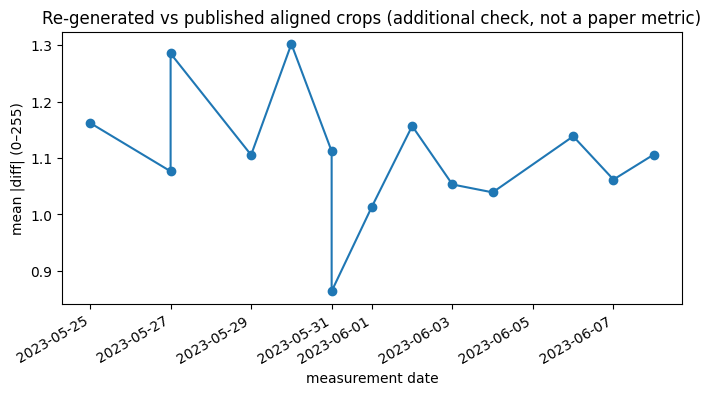

In [ ]:
import matplotlib.dates as mdates
from datetime import datetime

xs = [datetime.strptime(u.split("_")[0], "%Y%m%d") for u, d in zip(ds.image_uids, diffs) if d is not None]
ys = [d for d in diffs if d is not None]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, ys, "o-")
ax.set_ylabel("mean |diff| (0–255)")
ax.set_xlabel("measurement date")
ax.set_title("Re-generated vs published aligned crops (additional check, not a paper metric)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.show()

### Lesion instance tracking over the season

From the published `ts/instance_mask` products we count distinct lesion instances per frame (the mask value = instance ID) and the lesion-pixel fraction, and export a small CSV. This reproduces the paper's *symptom tracking* outputs for this leaf — the area-overlap tracking the authors describe — as delivered in the dataset.

*日本語:* 公開 instance mask から各フレームの lesion インスタンス数と病変画素割合を集計し、CSV に出力します（著者の area-overlap トラッキング成果物の集計）。

In [ ]:
import pandas as pd

rows = []
for k, (uid, im, lm) in enumerate(zip(ds.image_uids, ds.instance_masks, ds.leaf_masks)):
    if im is None:
        continue
    m = np.asarray(im)
    if m.ndim == 3:
        m = m[..., 0]
    rows.append({
        "frame": k,
        "image_uid": uid,
        "date": uid.split("_")[0],
        "n_lesion_instances": int(m.max()),
        "lesion_pixel_fraction": round(float((m > 0).mean()), 5),
        "leaf_mask_present": lm is not None,
    })
df = pd.DataFrame(rows)
df.to_csv("/content/sympathique/lesion_instances_ESWW0070020_1.csv", index=False)
df

,frame,image_uid,date,n_lesion_instances,lesion_pixel_fraction,leaf_mask_present
0,4,20230530_122548_ESWW0070020_1.JPG,20230530,2,0.00067,True
1,5,20230531_094332_ESWW0070020_1.JPG,20230531,4,0.00215,True
2,6,20230531_164152_ESWW0070020_1.JPG,20230531,6,0.00447,True
3,7,20230601_155601_ESWW0070020_1.JPG,20230601,10,0.01001,True
4,8,20230602_104754_ESWW0070020_1.JPG,20230602,12,0.01260,True
5,9,20230603_105040_ESWW0070020_1.JPG,20230603,16,0.01800,True
6,10,20230604_132542_ESWW0070020_1.JPG,20230604,21,0.03212,True
7,11,20230606_084622_ESWW0070020_1.JPG,20230606,26,0.05081,True
8,12,20230607_162917_ESWW0070020_1.JPG,20230607,32,0.07299,True
9,13,20230608_162957_ESWW0070020_1.JPG,20230608,39,0.10856,True


### Instance counts over time

The tracked lesion instances of this leaf as a function of date (an additional visualization created for this notebook, computed from the dataset's published tracking products; not an author figure). Leaf area loss / damage dynamics at cultivar level are reported in the paper's Fig. 5 from the full dataset — a single leaf is only an illustration.

*日本語:* 公開トラッキング成果物から、この葉の lesion インスタンス数の日付変化をプロットします（本ノートブック独自の追加可視化）。

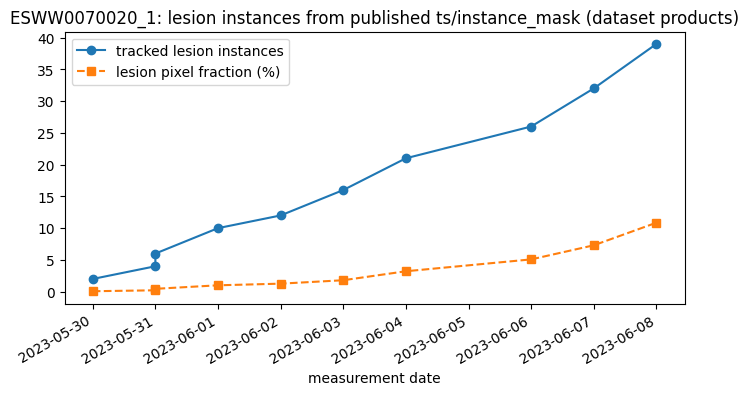

CSV written: /content/sympathique/lesion_instances_ESWW0070020_1.csv


In [ ]:
dx = [datetime.strptime(d, "%Y%m%d") for d in df["date"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dx, df["n_lesion_instances"], "o-", label="tracked lesion instances")
ax.plot(dx, df["lesion_pixel_fraction"] * 100, "s--", label="lesion pixel fraction (%)")
ax.set_xlabel("measurement date")
ax.legend()
ax.set_title(f"{LEAF_UID}: lesion instances from published ts/instance_mask (dataset products)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.show()
print("CSV written:", "/content/sympathique/lesion_instances_ESWW0070020_1.csv")

## Interpretation & validation record

**What was verified in this run**

- The dataset record DOI 10.3929/ethz-b-000739194 (CC-BY-4.0) links a public LibDrive share; its published layout (`raw/<year>/<event>`, `processed/{reg,ts}/<leaf_uid>`) matches the paper's *Data Records* section and the expectations of the authors' `DatasetTools`.
- The authors' `DatasetTools.LeafDataset` loads the published products unmodified after a pure path mapping (symlinks) — evidence that the published structure is the pipeline's output structure.
- `warp_images()` re-generated aligned crops from raw frames + published ROI/transforms and was compared against the published crops (table and plot above).
- Lesion instance counts were tabulated from the published tracking masks and exported to CSV.

**Limitations**

- One leaf, one season (`ESWW0070020_1`, 2023) — this is the paper's own suggested inspection use case, not a dataset-level reproduction of published statistics (e.g. the 0.16 mm median alignment error or Fig. 5 trends).
- Frames whose reference marks were washed off have no published transform; the author code prints a warning and falls back to the unaligned crop.
- The repository publishes no LICENSE file for the Python code; the dataset is CC-BY-4.0 (cite Anderegg 2025, ETH Zurich, and the paper).

**References**

- Anderegg, J. (2026). High-Resolution Leaf Image Sequences with Geometric Alignment for Dynamic Phenotyping of Foliar Diseases. *Scientific Data* 13:247. https://www.nature.com/articles/s41597-026-06567-y
- Dataset: https://doi.org/10.3929/ethz-b-000739194 (ETH Zurich, CC-BY-4.0)
- Code: https://github.com/and-jonas/sympathique-wheat @ `d580937d47a0083e177c0f9aa3effe22638ee139` (`DatasetTools/LeafImageSeries.py`, `DatasetTools/utils.py`)

*日本語:* 本ノートブックは、著者コードと公開データセットのみを用いて「1 葉系列の読み込みと検査」を実行しました。単一葉・単一季節の例示であり、論文のデータセット全体の統計（整合誤差 0.16 mm 中央値や Fig. 5 の動向）の再検証ではありません。データは CC-BY-4.0、コードリポジトリには LICENSE ファイルが無いため利用規約は論文の記載に従います。